# Импорты библиотек

In [178]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator
from IPython.display import display
from pathlib import Path

In [179]:
##Этих импортов не было в исходном ноутбуке, я вынес их отдельно
import scipy.stats

# Чтение данных

In [180]:
# Для отображения числе не в экспоненциальном виде, а обрезанными до двух знаков после запятой
pd.options.display.float_format = '{:.2f}'.format

In [181]:
project_dir = Path.cwd().parent
data_path = project_dir / 'data' / 'marketplace.csv'
df = pd.read_csv(data_path)
df.head()

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.00,138.78,0.00
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       25335 non-null  object 
 1   platform_num  25335 non-null  int64  
 2   first_login   25335 non-null  object 
 3   reg_dt        25331 non-null  object 
 4   browser       25335 non-null  object 
 5   first_buy     24361 non-null  object 
 6   target        25335 non-null  float64
 7   total_buy     25335 non-null  float64
 8   total_return  25335 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.7+ MB


In [183]:
#Приведение дат к datetime
date_cols = ["first_login", "reg_dt", "first_buy"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       25335 non-null  object        
 1   platform_num  25335 non-null  int64         
 2   first_login   25335 non-null  datetime64[ns]
 3   reg_dt        25331 non-null  datetime64[ns]
 4   browser       25335 non-null  object        
 5   first_buy     24361 non-null  datetime64[ns]
 6   target        25335 non-null  float64       
 7   total_buy     25335 non-null  float64       
 8   total_return  25335 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.7+ MB


In [184]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
platform_num,25335.00,6.47,17.02,1.00,2.00,3.00,6.00,674.00
target,25335.00,0.00,0.25,-3.43,0.00,0.00,0.00,0.30
total_buy,25335.00,898.55,6815.55,0.00,19.36,52.72,203.53,490447.99
total_return,25335.00,334.08,2882.91,0.00,0.00,0.00,0.00,207893.84


In [185]:
total_rows   = len(df)
unique_users = df["user_id"].nunique()
extra_rows   = total_rows - unique_users

dup_counts = (
    df["user_id"]
    .value_counts()
    .loc[lambda s: s > 1]
)

num_users_with_dups   = dup_counts.size
share_users_with_dups = (num_users_with_dups / unique_users * 100) if unique_users > 0 else 0.0
share_rows_with_dups  = (extra_rows / total_rows * 100) if total_rows > 0 else 0.0

print(f"Всего строк в датасете:                    {total_rows}")
print(f"Уникальных пользователей (user_id):        {unique_users}")
print(f"Лишних строк из-за дублей:                 {extra_rows} ({share_rows_with_dups:.3f}%)")
print(f"Пользователей, представленных >1 строкой:  {num_users_with_dups} ({share_users_with_dups:.3f}%)")

if num_users_with_dups > 0:
    print("\nСписок user_id с дублями и числом строк по каждому:")

    dup_df = (
        dup_counts
        .rename_axis("user_id")           
        .reset_index(name="row_count")
    )

    display(dup_df)
else:
    print("\nДублей по user_id не обнаружено.")

Всего строк в датасете:                    25335
Уникальных пользователей (user_id):        25331
Лишних строк из-за дублей:                 4 (0.016%)
Пользователей, представленных >1 строкой:  4 (0.016%)

Список user_id с дублями и числом строк по каждому:


,user_id,row_count
0,user_000072,2
1,user_000383,2
2,user_019702,2
3,user_006319,2


# Чистка данных

**Обнаружение дублей по пользователям**

На этапе проверки качества данных был проведён анализ уникальности идентификаторов пользователей (user_id).
Всего в датасете содержится 25 335 строк и 25 331 уникальный user_id, то есть 4 пользователя представлены двумя строками каждый.
Доля таких пользователей от всей клиентской базы составляет около 0,016 %, доля «лишних» строк — также порядка 0,016 %.
Формально влияние дублей на агрегированные показатели невелико, однако для корректного анализа на уровне пользователя важно, чтобы каждому user_id соответствовала ровно одна запись.

Поэтому было принято решение привести датасет к формату «одна строка = один пользователь».

**Алгоритм устранения дублей**

Так как данные представляют собой снимок состояния пользователей на определённые даты, для каждого user_id мы оставляем наиболее «свежий» срез. В качестве приближения к времени среза используем дату первого входа в личный кабинет (first_login):

1. Сортируем датафрейм по user_id и first_login по возрастанию.
В результате для каждого пользователя строки упорядочены от более ранних логинов к более поздним.

2. Удаляем дубликаты user_id, оставляя последнюю строку для каждого пользователя (keep="last"), то есть запись с максимально поздним first_login.

3. Сбрасываем индекс и дополнительно проверяем, что user_id стал уникален.

Таким образом, мы получаем очищенный датасет, в котором каждая строка соответствует одному пользователю в его последнем доступном состоянии.

In [186]:
rows_before = df.shape[0]

df_sorted = df.sort_values(["user_id", "first_login"])

df_clean = (
    df_sorted
    .drop_duplicates(subset="user_id", keep="last")
    .reset_index(drop=True)
)

df = df_clean.copy()
rows_after = df.shape[0]

print(f"Строк до очистки:                     {rows_before}")
print(f"Строк после очистки:                  {rows_after}")
print(f"Удалено строк:                        {rows_before - rows_after}")
print(f"user_id уникальны после очистки:      {df_clean['user_id'].is_unique}")

Строк до очистки:                     25335
Строк после очистки:                  25331
Удалено строк:                        4
user_id уникальны после очистки:      True


# Подготовка данных

Добавим столбец "target_unshifted", который вычислим по формуле:

$$
target_{unshifted} = 0.3 - target
$$

In [187]:
df_enriched = df.copy()

df_enriched['target_unshifted'] = 0.3 - df_enriched['target']


print('После:')
df_enriched.head(5)

После:


,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,target_unshifted
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00,0.30
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00,0.30
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00,0.00
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaT,0.00,138.78,0.00,0.30
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00,0.30


Добавим столбец is_bad_target, поделив клиентов по отношению возврат/покупка на "хороших" (target_unshifted < 0.3) и "плохих" (target_unshifted >= 0.3)

In [188]:
df_enriched['is_bad_target'] = df_enriched['target_unshifted'] >= 0.3
df_enriched.head(10)

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,target_unshifted,is_bad_target
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00,0.30,True
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00,0.30,True
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00,0.00,False
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaT,0.00,138.78,0.00,0.30,True
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00,0.30,True
5,user_000005,7,2025-03-27,2024-06-06,browser_02,2025-03-30,0.30,504.59,0.00,0.00,False
6,user_000006,4,2024-11-06,2024-08-14,browser_02,2024-09-28,0.00,20.96,0.00,0.30,True
7,user_000007,6,2024-10-04,2024-08-06,browser_03,2024-09-03,0.00,10.31,0.00,0.30,True
8,user_000008,3,2024-12-10,2024-08-10,browser_03,2025-04-15,0.00,36.33,0.00,0.30,True
9,user_000009,3,2025-01-22,2025-01-29,browser_01,2025-01-30,0.00,8.50,62.67,0.30,True


Добавим столбец hist_return_rate который вычислим следующим образом:

In [189]:
mask_no_buys     = df_enriched["total_buy"] == 0
mask_zero_ret    = (df_enriched["total_buy"] > 0) & (df_enriched["total_return"] == 0)
mask_nonzero_ret = (df_enriched["total_buy"] > 0) & (df_enriched["total_return"] > 0)


df_enriched["hist_return_rate"] = np.nan
df_enriched.loc[mask_nonzero_ret, "hist_return_rate"] = (
    df_enriched.loc[mask_nonzero_ret, "total_return"] /
    df_enriched.loc[mask_nonzero_ret, "total_buy"]
)

df_enriched.head(10)

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,target_unshifted,is_bad_target,hist_return_rate
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00,0.30,True,NaN
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00,0.30,True,NaN
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00,0.00,False,2.49
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaT,0.00,138.78,0.00,0.30,True,NaN
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00,0.30,True,NaN
5,user_000005,7,2025-03-27,2024-06-06,browser_02,2025-03-30,0.30,504.59,0.00,0.00,False,NaN
6,user_000006,4,2024-11-06,2024-08-14,browser_02,2024-09-28,0.00,20.96,0.00,0.30,True,NaN
7,user_000007,6,2024-10-04,2024-08-06,browser_03,2024-09-03,0.00,10.31,0.00,0.30,True,NaN
8,user_000008,3,2024-12-10,2024-08-10,browser_03,2025-04-15,0.00,36.33,0.00,0.30,True,NaN
9,user_000009,3,2025-01-22,2025-01-29,browser_01,2025-01-30,0.00,8.50,62.67,0.30,True,7.37


Добавим столбец с признаком "Редкий браузер"

In [190]:
counts = df_enriched['browser'].value_counts()

threshold = counts.quantile(0.75)
rare_browsers = counts[counts < threshold].index

df_enriched['is_rare_browser'] = df_enriched['browser'].isin(rare_browsers)
df_enriched.head(10)

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,target_unshifted,is_bad_target,hist_return_rate,is_rare_browser
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00,0.30,True,NaN,False
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00,0.30,True,NaN,False
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00,0.00,False,2.49,False
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaT,0.00,138.78,0.00,0.30,True,NaN,False
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00,0.30,True,NaN,False
5,user_000005,7,2025-03-27,2024-06-06,browser_02,2025-03-30,0.30,504.59,0.00,0.00,False,NaN,False
6,user_000006,4,2024-11-06,2024-08-14,browser_02,2024-09-28,0.00,20.96,0.00,0.30,True,NaN,False
7,user_000007,6,2024-10-04,2024-08-06,browser_03,2024-09-03,0.00,10.31,0.00,0.30,True,NaN,False
8,user_000008,3,2024-12-10,2024-08-10,browser_03,2025-04-15,0.00,36.33,0.00,0.30,True,NaN,False
9,user_000009,3,2025-01-22,2025-01-29,browser_01,2025-01-30,0.00,8.50,62.67,0.30,True,7.37,False


# Гипотезы

### Гипотеза 3

Проанализируем клиентов в контексте исторических возвратов.

Будем работать с подмножеством клиентов, у которых вообще есть исторические возвраты:

In [191]:
df_hist_return_exists =  df_enriched.dropna(subset='hist_return_rate')
print(df_hist_return_exists['user_id'].count())
df_hist_return_exists.head(10)

5247


,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,target_unshifted,is_bad_target,hist_return_rate,is_rare_browser
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00,0.00,False,2.49,False
9,user_000009,3,2025-01-22,2025-01-29,browser_01,2025-01-30,0.00,8.50,62.67,0.30,True,7.37,False
17,user_000017,3,2025-03-28,2024-05-21,browser_05,2025-03-13,0.00,226.49,40.00,0.30,True,0.18,True
27,user_000027,6,2025-01-27,2025-01-20,browser_02,2025-01-11,0.00,101.26,401.00,0.30,True,3.96,False
29,user_000029,8,2025-03-30,2023-12-12,browser_02,2025-03-19,0.00,6.85,111.25,0.30,True,16.24,False
30,user_000030,5,2025-03-24,2024-12-19,browser_08,2025-03-30,0.00,6516.05,4830.00,0.30,True,0.74,True
31,user_000031,3,2025-03-30,2023-04-02,browser_01,2025-03-23,0.00,529.14,352.23,0.30,True,0.67,False
35,user_000035,150,2024-10-17,2024-07-19,browser_03,2024-09-24,0.15,4525.14,2200.07,0.15,False,0.49,False
39,user_000039,4,2024-10-26,2024-02-24,browser_02,2024-02-23,0.00,25431.89,6482.80,0.30,True,0.25,False
47,user_000047,17,2024-09-29,2023-08-28,browser_01,2023-09-16,0.00,102.69,45.06,0.30,True,0.44,False


Посмотрим, что представляет из себя распределение клиентов по историческим возвратам

Медиана: 0.6329757269145337


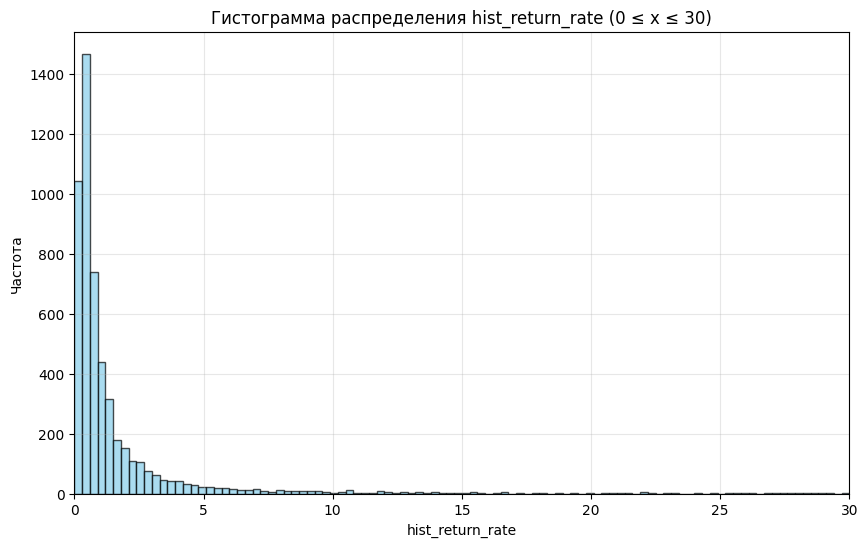

In [192]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Определяем бины в диапазоне [0, 30]
bin_edges = np.linspace(0, 30, num=101)  # 100 бинов от 0 до 30 (101 точка = 100 интервалов)

# Гистограмма с явными границами бинов
plt.hist(
    df_hist_return_exists['hist_return_rate'],
    bins=bin_edges,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

print(f"Медиана: {df_hist_return_exists['hist_return_rate'].median()}")

# Оформление
plt.xlabel('hist_return_rate')
plt.ylabel('Частота')
plt.xlim(0, 30)  # Ограничиваем видимую область
plt.ylim(bottom=0)   # Гарантируем, что ось Y начинается с 0
plt.title('Гистограмма распределения hist_return_rate (0 ≤ x ≤ 30)')
plt.grid(True, alpha=0.3)
plt.show()


Из графика очевидно, что распределение не нормальное, и что у половины клиентов исторический возврат не превышает 0,63.

Разобьем клиентов с историческим возвратом на две группы (справа и слева от медианы), и посмотрим, нет ли каких-то особенностей у этих групп

Начнем с количества устройств. Определим вид распределения в подгруппах по количеству исторических возвратов (strange: hist_return_rate>=0.63; ok: hist_return_rate<0.63>):

In [193]:
df_strange_hist_return = (df_hist_return_exists[df_hist_return_exists['hist_return_rate']>=0.63])['platform_num']
df_ok_hist_return = (df_hist_return_exists[df_hist_return_exists['hist_return_rate']<0.63])['platform_num']

df_strange_hist_return_std = scipy.stats.zscore(df_strange_hist_return)
df_ok_hist_return_std = scipy.stats.zscore(df_ok_hist_return)

_, p_value_strange = scipy.stats.kstest(df_strange_hist_return_std, 'norm')
_, p_value_ok = scipy.stats.kstest(df_ok_hist_return_std, 'norm')

print(f'bad_target is norm: {p_value_strange >= 0.05}')
print(f'good_target is norm: {p_value_ok >= 0.05}')


bad_target is norm: False
good_target is norm: False


Видим, значения в подгруппах не распределены нормально. Сравним количество устройств в подгруппах с использованием критерия Манна-Уитни:

U-value: 2505215.5000
p-значение: 0.0000
Медианное число устройств у пользователей с большим количеством возвратов: 4.0
Медианное число устройств у пользователей с приемлемым количеством возвратов: 6.0


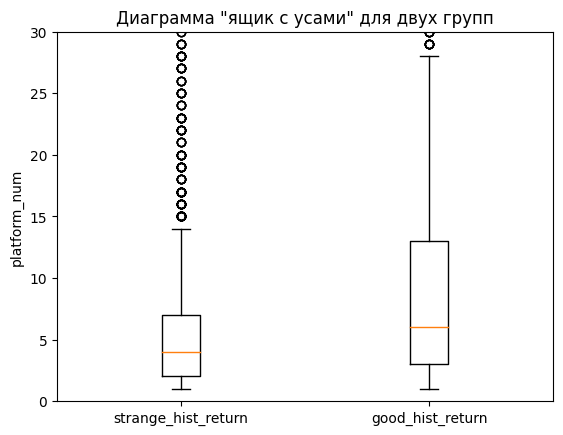

In [194]:
res = scipy.stats.mannwhitneyu(df_strange_hist_return, df_ok_hist_return, alternative='two-sided')
print(f"U-value: {res.statistic:.4f}")
print(f"p-значение: {res.pvalue:.4f}")

print(f"Медианное число устройств у пользователей с большим количеством возвратов: {df_strange_hist_return.median()}")
print(f"Медианное число устройств у пользователей с приемлемым количеством возвратов: {df_ok_hist_return.median()}")


# Строим boxplot
plt.boxplot([df_strange_hist_return, df_ok_hist_return], labels=['strange_hist_return', 'good_hist_return'])
plt.title('Диаграмма "ящик с усами" для двух групп')
plt.ylim(0,30)
plt.ylabel('platform_num')
plt.show()

Отсюда делаем вывод:
- ✍️ Пользователи, которые меньше возвращали заказов в прошлом, имеют больше привязанных аккаунтов к устройству (медианное значение: 6 против 4)

Далее рассмотрим исторические возвраты более абстрактно - нет ли корреляции между количеством устройств и уровнем возвратов в прошлом?


Вычислим корреляцию по Спирмену:

In [195]:
platform_num_hist_return_corr_obj = scipy.stats.spearmanr(df_hist_return_exists['platform_num'], df_hist_return_exists['hist_return_rate'])
p_value = platform_num_hist_return_corr_obj[1]
corr_value = platform_num_hist_return_corr_obj[0]

print(f'p-value: {p_value:.4f}; corr: {corr_value:.4f}')


p-value: 0.0000; corr: -0.2469


Видим, что между количеством устройств и уровнем исторических возвратов существует статистически значимая слабая обратная корреляция

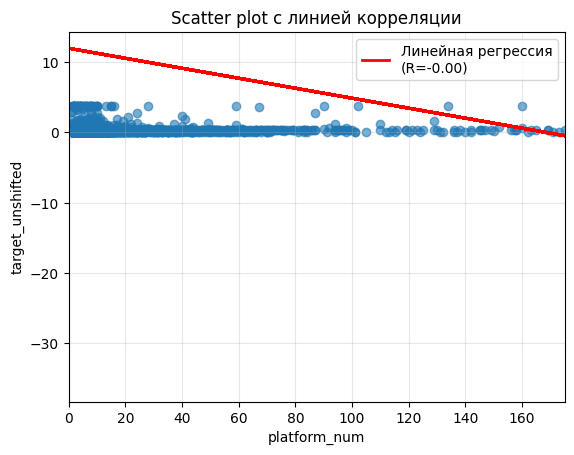

In [219]:
## График

plt.scatter(df_hist_return_exists['platform_num'], df_hist_return_exists['target_unshifted'], alpha=0.6)


# Строим линейную регрессию
slope, intercept, r_value, p_value_lin, std_err = scipy.stats.linregress(
    df_hist_return_exists['platform_num'], 
    df_hist_return_exists['hist_return_rate']
)

# Вычисляем предсказанные значения (y = slope * x + intercept)
x_vals = df_enriched['platform_num']
y_pred = slope * x_vals + intercept

# Добавляем линию регрессии
plt.plot(x_vals, y_pred, color='red', linewidth=2, label=f'Линейная регрессия\n(R={r_value:.2f})')

# Оформляем график
plt.xlabel('platform_num')
plt.ylabel('target_unshifted')
plt.xlim(0, 175)
plt.title('Scatter plot с линией корреляции')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Отсюда делаем вывод:
- ✍️ Количество возвратов в прошлом имеет слабую обратную корреляцию с количеством устройств, привязанных к аккаунту
- ✍️ Пользователи с большим количеством привязанных устройств делали меньше возвратов в прошлом

### Гипотеза 5

Для начала бегло оценим, различается ли вообще количество устройств у "хороших" клиентов (target_unshifted < 0.3) и "плохих" (target_unshifted >= 0.3)

Первым делом, проверим выборки на нормальность c помощью критерия Колмогорова-Смирнова, чтобы корректно выбрать статистический критерий.

- NB: Здесь и далее считаем статистически значимыми различия при р <0.05


In [197]:
bad_target_devices = (df_enriched[df_enriched['is_bad_target']==True])['platform_num']
good_target_devices = (df_enriched[df_enriched['is_bad_target']==False])['platform_num']

bad_target_std = scipy.stats.zscore(bad_target_devices)
good_target_std = scipy.stats.zscore(good_target_devices)

_, p_value_bad = scipy.stats.kstest(bad_target_std, 'norm')
_, p_value_good = scipy.stats.kstest(good_target_std, 'norm')

print(f'bad_target is norm: {p_value_bad >= 0.05}')
print(f'good_target is norm: {p_value_good >= 0.05}')

bad_target is norm: False
good_target is norm: False


Наши выборки независимы, несогласуются с нормальным законом, и их две. Это значит, что для их сравнения подойдет U-критерий Манна-Уитни

U-value: 14709906.5000
p-значение: 0.0000
Медианное число устройств у пользователей с большим количеством возвратов: 3.0
Медианное число устройств у пользователей с приемлемым количеством возвратов: 6.0


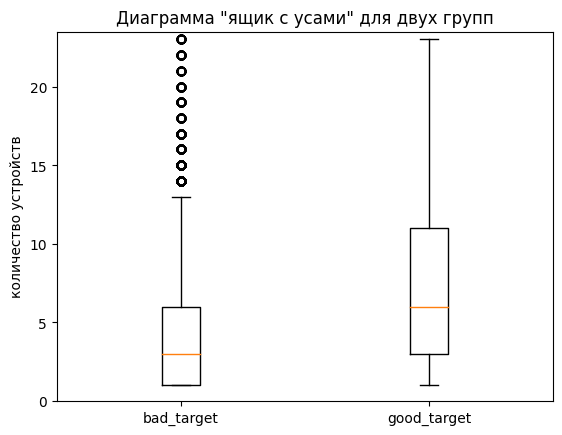

In [216]:
## 
bad_target = df_enriched[df_enriched['is_bad_target']==True]
good_target = df_enriched[df_enriched['is_bad_target']==False]


##Проверка на нормальность



res = scipy.stats.mannwhitneyu(bad_target['platform_num'], good_target['platform_num'], alternative='two-sided')
print(f"U-value: {res.statistic:.4f}")
print(f"p-значение: {res.pvalue:.4f}")

print(f"Медианное число устройств у пользователей с большим количеством возвратов: {bad_target['platform_num'].median()}")
print(f"Медианное число устройств у пользователей с приемлемым количеством возвратов: {good_target['platform_num'].median()}")


# Строим boxplot
plt.boxplot([bad_target['platform_num'], good_target['platform_num']], labels=['bad_target', 'good_target'])
plt.title('Диаграмма "ящик с усами" для двух групп')
plt.ylim(0,23.5)
plt.ylabel('количество устройств')
plt.show()

Наблюдаем статистически значимое различие в количестве устройств у "плохих" и "хороших" клиентов: медианное количество устройств у "хороших" вдвое больше, чем у "плохих" (6 против 3).
Таким образом, делаем вывод:

- ✍️ Пользователи, которые реже делают возвраты, в среднем сидят с большего количество устройств.

Проверим, есть ли статистически значимая корреляция между количеством устройств у пользователя и значением target

Статистически значимыми будем считать результаты при P < 0.05

In [199]:
##Вычисления


target_unshifted_platform_corr_obj = scipy.stats.spearmanr(df_enriched['platform_num'], df_enriched['target_unshifted'])
p_value = target_unshifted_platform_corr_obj[1]
corr_value = target_unshifted_platform_corr_obj[0]

print(f'p-value: {p_value:.4f}; corr: {corr_value:.4f}')


p-value: 0.0000; corr: -0.1282


Наблюдаем статистически значимую слабую отрицательную корреляцию между platform_num и target_unshifted.

Таким образом, можем сделать выводы:
- ✍️ есть статистически значимая слабая взаимосвязь между количеством устройств и количеством возвратов
- ✍️ чем больше устройств у аккаунта, тем ниже доля возвратов к покупкам

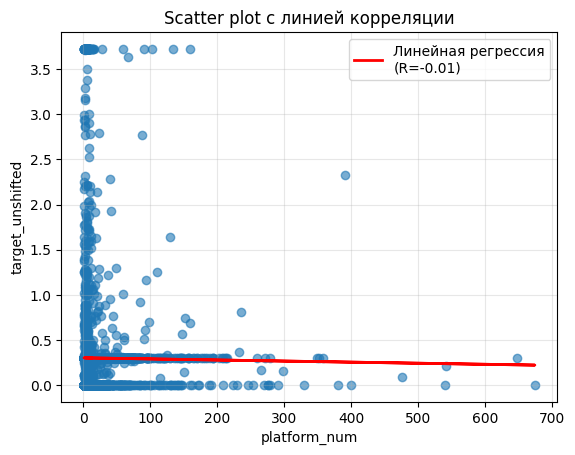

In [200]:
## График

plt.scatter(df_enriched['platform_num'], df_enriched['target_unshifted'], alpha=0.6)


# Строим линейную регрессию
slope, intercept, r_value, p_value_lin, std_err = scipy.stats.linregress(
    df_enriched['platform_num'], 
    df_enriched['target_unshifted']
)

# Вычисляем предсказанные значения (y = slope * x + intercept)
x_vals = df_enriched['platform_num']
y_pred = slope * x_vals + intercept

# Добавляем линию регрессии
plt.plot(x_vals, y_pred, color='red', linewidth=2, label=f'Линейная регрессия\n(R={r_value:.2f})')

# Оформляем график
plt.xlabel('platform_num')
plt.ylabel('target_unshifted')
plt.title('Scatter plot с линией корреляции')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Гипотеза Х

Здесь пока просто накидал наброски, хочу с вами обсудить, перед тем как подробно описывать

1. Нет статистически значимых различий в количестве устройств между пользователями с редкими и популярными браузерами
2. Нет статистически значимых различий в таргете -||-

U-value: 20081539.5000
p-значение: 0.4844
Медианное число устройств у пользователей с большим количеством возвратов: 3.0
Медианное число устройств у пользователей с приемлемым количеством возвратов: 3.0


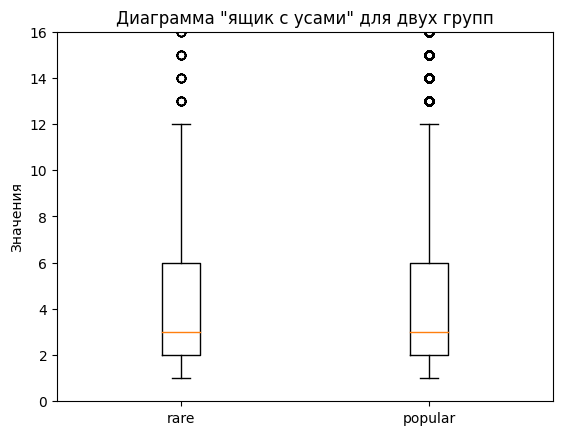

In [212]:
## 
rare_browser = df_enriched[df_enriched['is_rare_browser']==True]
popular_browser = df_enriched[df_enriched['is_rare_browser']==False]

res = scipy.stats.mannwhitneyu(rare_browser['platform_num'], popular_browser['platform_num'], alternative='two-sided')
print(f"U-value: {res.statistic:.4f}")
print(f"p-значение: {res.pvalue:.4f}")

print(f"Медианное число устройств у пользователей с большим количеством возвратов: {rare_browser['platform_num'].median()}")
print(f"Медианное число устройств у пользователей с приемлемым количеством возвратов: {popular_browser['platform_num'].median()}")


# Строим boxplot
plt.boxplot([rare_browser['platform_num'], popular_browser['platform_num']], labels=['rare', 'popular'])
plt.title('Диаграмма "ящик с усами" для двух групп')
plt.ylim(0,16)
plt.ylabel('Значения')
plt.show()

U-value: 20411807.0000
p-значение: 0.3806
Медианный несмещенный таргет у редких бразуеров: 0.3
Медианный несмещенный таргет у популярных бразуеров: 0.3


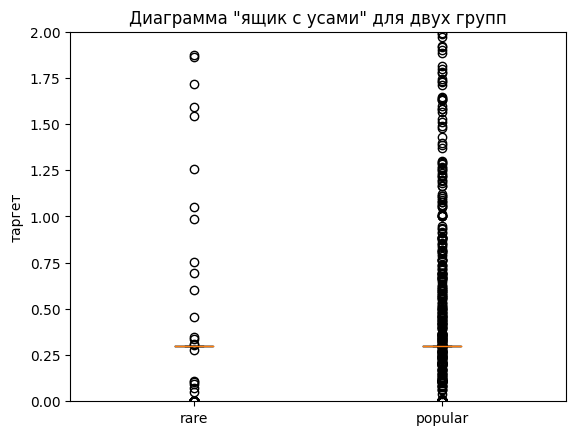

In [215]:
## 
rare_browser = df_enriched[df_enriched['is_rare_browser']==True]
popular_browser = df_enriched[df_enriched['is_rare_browser']==False]

res = scipy.stats.mannwhitneyu(rare_browser['target_unshifted'], popular_browser['target_unshifted'], alternative='two-sided')
print(f"U-value: {res.statistic:.4f}")
print(f"p-значение: {res.pvalue:.4f}")

print(f"Медианный несмещенный таргет у редких бразуеров: {rare_browser['target_unshifted'].median()}")
print(f"Медианный несмещенный таргет у популярных бразуеров: {popular_browser['target_unshifted'].median()}")


# Строим boxplot
plt.boxplot([rare_browser['target_unshifted'], popular_browser['target_unshifted']], labels=['rare', 'popular'])
plt.title('Диаграмма "ящик с усами" для двух групп')
plt.ylim(0,2,0.4)
plt.ylabel('таргет')
plt.show()